In [1]:
# Understand patterns, relationships, distributions, and possible problems in the data before modeling.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# import plotly.express as px
# import plotly.graph_objects as go
from pathlib import Path


In [3]:

df=pd.read_csv(Path("../data/raw/ds_salaries.csv"))
print(df.shape)

df.head()

df.tail()
df.sample(5)
df.info()

(607, 12)
<class 'pandas.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Unnamed: 0          607 non-null    int64
 1   work_year           607 non-null    int64
 2   experience_level    607 non-null    str  
 3   employment_type     607 non-null    str  
 4   job_title           607 non-null    str  
 5   salary              607 non-null    int64
 6   salary_currency     607 non-null    str  
 7   salary_in_usd       607 non-null    int64
 8   employee_residence  607 non-null    str  
 9   remote_ratio        607 non-null    int64
 10  company_location    607 non-null    str  
 11  company_size        607 non-null    str  
dtypes: int64(5), str(7)
memory usage: 57.0 KB


In [13]:
df_clean_view = df.drop(columns=["Unnamed: 0"], errors="ignore")

df_clean_view.head()

columns_cleanView=df_clean_view.select_dtypes(include="object").columns.tolist()
int_col_cleanView=df_clean_view.select_dtypes(include=["int64","float64"]).columns.tolist()
print(columns_cleanView)
int_col_cleanView




['experience_level', 'employment_type', 'job_title', 'salary_currency', 'employee_residence', 'company_location', 'company_size']


/tmp/ipykernel_706045/3509592423.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columns_cleanView=df_clean_view.select_dtypes(include="object").columns.tolist()


['work_year', 'salary', 'salary_in_usd', 'remote_ratio']

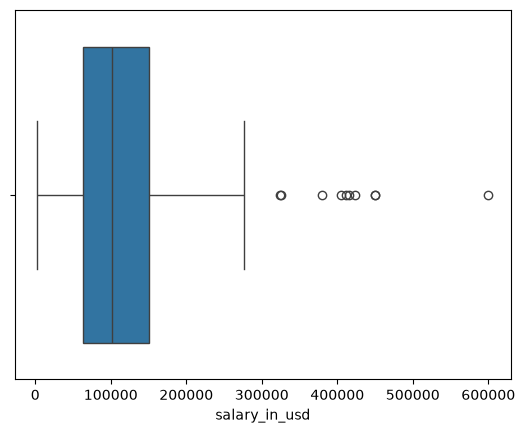

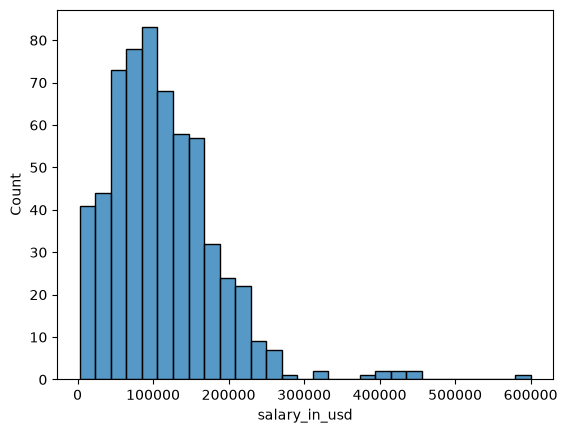

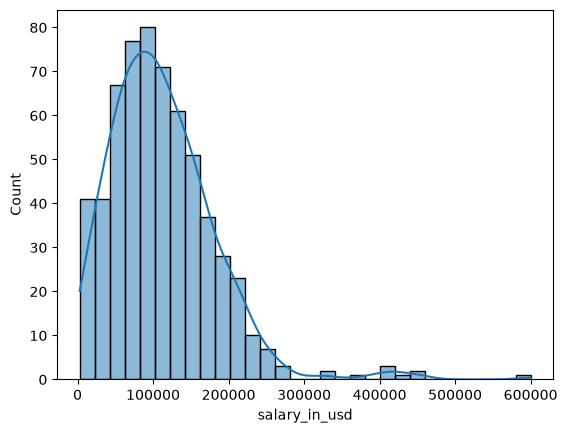

In [14]:
box_plot_salary_usd=sns.boxplot(x=df_clean_view['salary_in_usd'])
plt.show()

hist_plot_salary_usd=sns.histplot(df_clean_view['salary_in_usd'])
plt.show()
sns.histplot(
    df_clean_view['salary_in_usd'],
    bins=30,
    kde=True
)
plt.show()








In [ ]:
analyze_salary_mean=df_clean_view.groupby("experience_level")["salary_in_usd"].mean()
print(analyze_salary_mean)


analyze_salary_median=df_clean_view.groupby("experience_level")["salary_in_usd"].median()
analyze_salary_median



summary = df_clean_view.groupby("experience_level")["salary_in_usd"].agg(
    ["mean","median","min","max"]
)

print(summary)


# 1. Salary increases steadily with experience level.
# 2. EN < MI < SE < EX for both mean and median salary.
# 3. Executive roles earn the highest salaries.
# 4. Mean salary exceeds median salary across all experience levels.
# 5. This suggests a right-skewed salary distribution with high-income outliers.
# 6. Median salary is a more robust measure of central tendency for salary analysis.
# 7. The relationship between experience and salary is clearly positive.

experience_level
EN     61643.318182
EX    199392.038462
MI     87996.056338
SE    138617.292857
Name: salary_in_usd, dtype: float64
                           mean    median    min     max
experience_level                                        
EN                 61643.318182   56500.0   4000  250000
EX                199392.038462  171437.5  69741  600000
MI                 87996.056338   76940.0   2859  450000
SE                138617.292857  135500.0  18907  412000


In [29]:
summary = df_clean_view.groupby("employment_type")["salary_in_usd"].agg(
    ["mean","median","min","max"]
)
company_size_salary = df_clean_view.groupby("company_size")["salary_in_usd"].agg(
    ["mean","median","min","max"]
)
remote_ratio = df_clean_view.groupby("remote_ratio")["salary_in_usd"].agg(
    ["mean","median","min","max"]
)



print(summary)
print(company_size_salary)
print(remote_ratio)

                          mean    median    min     max
employment_type                                        
CT               184575.000000  105000.0  31875  416000
FL                48000.000000   40000.0  12000  100000
FT               113468.073129  104196.5   2859  600000
PT                33070.500000   18817.5   5409  100000
                       mean    median   min     max
company_size                                       
L             119242.994949  100000.0  5882  600000
M             116905.466258  113188.0  4000  450000
S              77632.674699   65000.0  2859  416000
                       mean    median   min     max
remote_ratio                                       
0             106354.622047   99000.0  2859  450000
50             80823.030303   69999.0  5409  423000
100           122457.454068  115000.0  4000  600000


In [32]:
avg_saaary_job_title=df_clean_view.groupby("job_title")["salary_in_usd"].mean()
print(avg_saaary_job_title)

country_origin=df_clean_view.groupby("company_location")["salary_in_usd"].mean()
print(country_origin)




job_title
3D Computer Vision Researcher                 5409.000000
AI Scientist                                 66135.571429
Analytics Engineer                          175000.000000
Applied Data Scientist                      175655.000000
Applied Machine Learning Scientist          142068.750000
BI Data Analyst                              74755.166667
Big Data Architect                           99703.000000
Big Data Engineer                            51974.000000
Business Data Analyst                        76691.200000
Cloud Data Engineer                         124647.000000
Computer Vision Engineer                     44419.333333
Computer Vision Software Engineer           105248.666667
Data Analyst                                 92893.061856
Data Analytics Engineer                      64799.250000
Data Analytics Lead                         405000.000000
Data Analytics Manager                      127134.285714
Data Architect                              177873.909091
Data

In [33]:
df_clean_view.corr(numeric_only=True)

,work_year,salary,salary_in_usd,remote_ratio
work_year,1.000000,-0.087577,0.170493,0.076314
salary,-0.087577,1.000000,-0.083906,-0.014608
salary_in_usd,0.170493,-0.083906,1.000000,0.132122
remote_ratio,0.076314,-0.014608,0.132122,1.000000


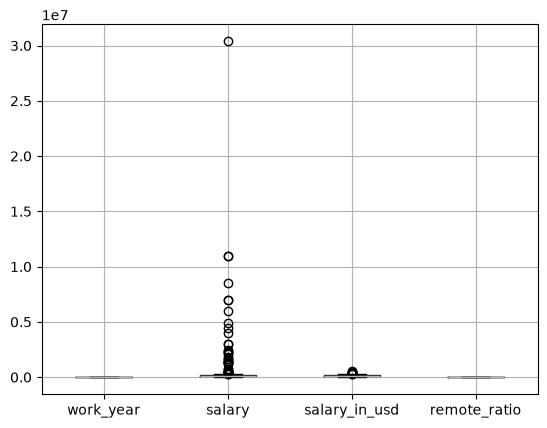

In [34]:
df_clean_view.boxplot()
plt.show()

## Missing EDA Checks Added

The next sections complete the remaining Step 2 EDA work:

- category counts with salary summaries
- reliable top job-title analysis using minimum record counts
- employee residence salary analysis
- grouped salary visualizations
- correlation heatmap
- outlier observation
- final EDA summary

In [ ]:
# Category counts: always compare salary summary with number of records.
category_columns = [
    "experience_level",
    "employment_type",
    "company_size",
    "remote_ratio",
    "job_title",
    "company_location",
    "employee_residence",
]

for column in category_columns:
    print("=" * 80)
    print(f"Column: {column}")
    print("\nCounts:")
    print(df_clean_view[column].value_counts().head(15))
    print("\nSalary summary:")
    print(
        df_clean_view.groupby(column)["salary_in_usd"]
        .agg(["count", "mean", "median", "min", "max"])
        .sort_values("mean", ascending=False)
        .head(15)
    )
    print()

## Reliable Job Title Analysis

Averages can be misleading when a job title appears only once or twice. For this reason, we compare:

- most common job titles
- highest average salary job titles overall
- highest average salary job titles with at least 5 records

In [ ]:
job_title_summary = (
    df_clean_view.groupby("job_title")["salary_in_usd"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)

print("Top 10 most common job titles:")
display(df_clean_view["job_title"].value_counts().head(10))

print("Top 10 highest paying job titles overall:")
display(job_title_summary.head(10))

print("Top 10 highest paying job titles with at least 5 records:")
display(job_title_summary[job_title_summary["count"] >= 5].head(10))

## Country And Residence Analysis

`company_location` tells us where the company is based.

`employee_residence` tells us where the employee lives.

Both can influence salary, especially for remote roles.

In [ ]:
company_location_summary = (
    df_clean_view.groupby("company_location")["salary_in_usd"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)

employee_residence_summary = (
    df_clean_view.groupby("employee_residence")["salary_in_usd"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)

print("Top 10 company locations by average salary:")
display(company_location_summary.head(10))

print("Top 10 company locations with at least 5 records:")
display(company_location_summary[company_location_summary["count"] >= 5].head(10))

print("Top 10 employee residences by average salary:")
display(employee_residence_summary.head(10))

print("Top 10 employee residences with at least 5 records:")
display(employee_residence_summary[employee_residence_summary["count"] >= 5].head(10))

## Grouped Salary Visualizations

Boxplots help compare salary distributions across categories. They show median, spread, and possible outliers.

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean_view, x="experience_level", y="salary_in_usd")
plt.title("Salary by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Salary in USD")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean_view, x="employment_type", y="salary_in_usd")
plt.title("Salary by Employment Type")
plt.xlabel("Employment Type")
plt.ylabel("Salary in USD")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean_view, x="company_size", y="salary_in_usd")
plt.title("Salary by Company Size")
plt.xlabel("Company Size")
plt.ylabel("Salary in USD")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean_view, x="remote_ratio", y="salary_in_usd")
plt.title("Salary by Remote Ratio")
plt.xlabel("Remote Ratio")
plt.ylabel("Salary in USD")
plt.show()

## Correlation Heatmap

Correlation shows linear relationships between numeric columns. It does not explain categorical relationships directly.

In [ ]:
numeric_columns = df_clean_view.select_dtypes(include=["number"]).columns
correlation_matrix = df_clean_view[numeric_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix for Numeric Columns")
plt.show()

correlation_matrix

## Outlier Detection

Salary datasets often contain outliers because some roles, countries, companies, or executive positions pay much more than the average.

In this step, we only detect and understand outliers. We do not remove them yet.

In [ ]:
q1 = df_clean_view["salary_in_usd"].quantile(0.25)
q3 = df_clean_view["salary_in_usd"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df_clean_view[
    (df_clean_view["salary_in_usd"] < lower_bound)
    | (df_clean_view["salary_in_usd"] > upper_bound)
]

print(f"Q1: {q1}")
print(f"Q3: {q3}")
print(f"IQR: {iqr}")
print(f"Lower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")
print(f"Number of outliers: {len(outliers)}")
print(f"Outlier percentage: {(len(outliers) / len(df_clean_view)) * 100:.2f}%")

outliers.sort_values("salary_in_usd", ascending=False).head(10)

## EDA Summary

Write your final EDA conclusions here after running the notebook.

Suggested points to answer:

1. The salary distribution appears right-skewed because a small number of records have very high salaries.
2. Executive and senior experience levels generally show higher salaries than entry and mid-level roles.
3. Employment type salary comparisons should be interpreted carefully because some categories may have very few records.
4. Company size appears related to salary, but the difference should be checked using both mean and median.
5. Remote ratio appears related to salary, but we should compare category counts before making strong conclusions.
6. Job title analysis must use counts because rare job titles can create misleading averages.
7. Country analysis must also use counts because some countries have very few records.
8. Outliers exist in `salary_in_usd`, but they should not be removed automatically because high salaries may be valid.
9. Before modeling, categorical columns will need encoding and salary leakage columns must be excluded.